##### Trendfolge 200d rolling avg


In [59]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path


In [60]:


if Path("/data/spy.csv").exists():
    print("file already exists")
else:
    spy = yf.download("SPY", start="1993-01-01", auto_adjust=True, multi_level_index=False)
    spy.to_csv("./data/spy.csv")

data = pd.read_csv("./data/spy.csv", index_col=0, parse_dates=True)
data.head(5)

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
1993-01-29,24.053516,24.070624,23.950870,24.070624,1003200
1993-02-01,24.224604,24.224604,24.070634,24.070634,480500
1993-02-02,24.275934,24.293042,24.156180,24.207503,201300
1993-02-03,24.532541,24.549649,24.293033,24.310140,529400
1993-02-04,24.635195,24.686518,24.344363,24.618087,531500


check for duplicates

In [61]:
print(f"First available date: {data.index[0].date()}")
print(f"Last available date: {data.index[-1].date()}")
print(f"Number of trading days: {len(data)}")

print(f"Number of duplicates: {data.index.duplicated().sum()}")
print(f"Sorted by date: {data.index.is_monotonic_increasing}")

First available date: 1993-01-29
Last available date: 2026-10-09
Number of trading days: 8482
Number of duplicates: 0
Sorted by date: True


#### PLot closing price lin and log

<Axes: title={'center': 'SPY, logarithmic axis'}, xlabel='Date'>

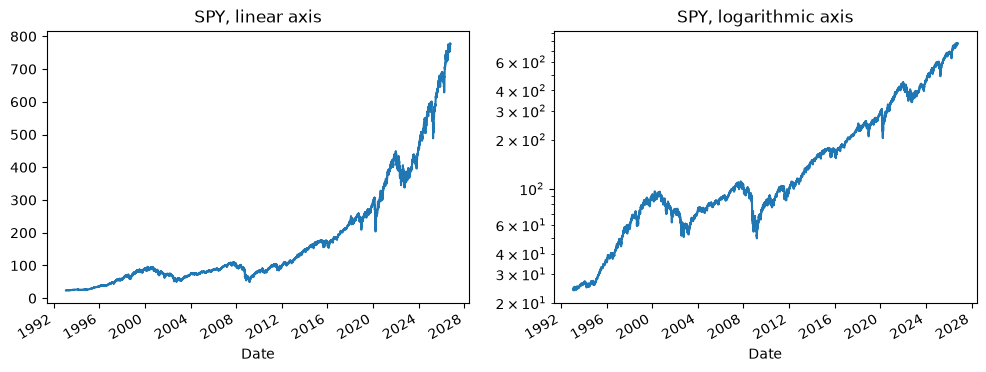

In [62]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,4))

data["Close"].plot(ax=ax1, title="SPY, linear axis")
data["Close"].plot(ax=ax2, title="SPY, logarithmic axis", logy=True)

In [ ]:
data["rendite"] = data["Close"].pct_change().fillna(0)
data["wert_bh"] = (1 + data["rendite"]).cumprod()
data.tail(10)

,Close,High,Low,Open,Volume,rendite,wert_bh
Date,,,,,,,
1993-01-29,24.053516,24.070624,23.950870,24.070624,1003200,0.000000,1.000000
1993-02-01,24.224604,24.224604,24.070634,24.070634,480500,0.007113,1.007113
1993-02-02,24.275934,24.293042,24.156180,24.207503,201300,0.002119,1.009247
1993-02-03,24.532541,24.549649,24.293033,24.310140,529400,0.010570,1.019915
1993-02-04,24.635195,24.686518,24.344363,24.618087,531500,0.004184,1.024183
1993-02-05,24.618076,24.669400,24.481214,24.618076,492100,-0.000695,1.023471
1993-02-08,24.618076,24.703615,24.583861,24.618076,596100,0.000000,1.023471
1993-02-09,24.447012,24.532551,24.395689,24.532551,122100,-0.006949,1.016359
1993-02-10,24.481211,24.498318,24.378564,24.446995,379600,0.001399,1.017781


In [66]:
## check if both values are equal 

print(data["wert_bh"].iloc[-1])
print(data["Close"].iloc[-1] / data["Close"].iloc[0])

# get 5 days with largest gains and losses
print(f"5 Tage mit größtem Gewinn: {data["rendite"].nlargest(5)}")
print(f"5 Tage mit größtem Verlust: {data["rendite"].nsmallest(5)}")



32.27516868250377
32.2751686825042
5 Tage mit größtem Gewinn: Date
2008-10-13    0.145198
2008-10-28    0.116855
2025-04-09    0.105019
2020-03-24    0.090603
2020-03-13    0.085486
Name: rendite, dtype: float64
5 Tage mit größtem Verlust: Date
2020-03-16   -0.109423
2008-10-15   -0.098447
2020-03-12   -0.095677
2008-12-01   -0.088578
2008-09-29   -0.078361
Name: rendite, dtype: float64


In [69]:
# simple moving average (SMA)
TIMEFRAME = 200 
data["sma"] = data["Close"].rolling(window=TIMEFRAME).mean()
data["Signal"] = np.where(data["Close"] > data["sma"], 1.0, 0.0)
data["Signal"] = data["Signal"].where(data["sma"].notna())
data["Position"] = data["Signal"].shift(1)

print(f"Anteil Tage investiert: {data['Position'].mean():.1%}")


Anteil Tage investiert: 77.4%


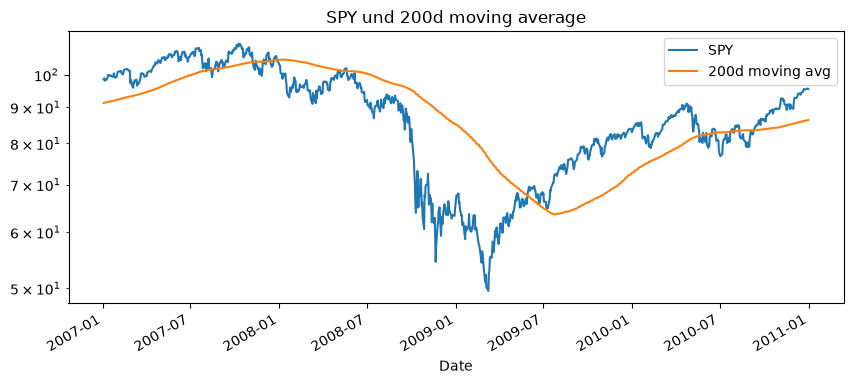

In [73]:
ax = data.loc["2007":"2010", ["Close", "sma"]].plot(logy=True, figsize=(10,4), title="SPY und 200d moving average")
ax.legend(["SPY", "200d moving avg"])
plt.show()